In [2]:
# import zipfile

# !wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# # Unzip the downloaded file
# zip_ref = zipfile.ZipFile("pizza_steak.zip")
# zip_ref.extractall()
# zip_ref.close()

In [3]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [4]:
print("TF version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

TF version: 2.16.2
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import urllib.request

url = "https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip"
urllib.request.urlretrieve(url, "pizza_steak.zip")

('pizza_steak.zip', <http.client.HTTPMessage at 0x13d9ba6d0>)

In [6]:
import os
print(os.path.getsize("pizza_steak.zip"))

109540975


In [7]:
# from pathlib import Path

# p = Path("pizza_steak.zip")
# print(p)

In [8]:
import zipfile
# Unzip the downloaded file
zip_ref = zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

In [9]:
!ls pizza_steak

test  train


In [10]:
!ls pizza_steak/test/

pizza steak


In [11]:
!ls pizza_steak/train/pizza/

1008104.jpg 1638227.jpg 2235981.jpg 2774899.jpg 3464027.jpg 576236.jpg
1008144.jpg 1646974.jpg 2236914.jpg 2775763.jpg 3464858.jpg 5764.jpg
1008844.jpg 1649108.jpg 2241448.jpg 2778214.jpg 3473991.jpg 579691.jpg
1008941.jpg 1649276.jpg 2247711.jpg 277963.jpg  3475936.jpg 593400.jpg
1011404.jpg 1652943.jpg 2253670.jpg 2785084.jpg 3478964.jpg 59445.jpg
102037.jpg  1654444.jpg 2255361.jpg 2793535.jpg 3479875.jpg 596494.jpg
1026922.jpg 1660415.jpg 2274117.jpg 27963.jpg   3479936.jpg 598381.jpg
1029698.jpg 1663749.jpg 2279642.jpg 2800325.jpg 3484590.jpg 604977.jpg
1033251.jpg 1665654.jpg 2280345.jpg 2811032.jpg 3493457.jpg 608085.jpg
1035854.jpg 166823.jpg  2285269.jpg 282013.jpg  349946.jpg  618021.jpg
1038357.jpg 1670471.jpg 2285942.jpg 2821034.jpg 350358.jpg  61822.jpg
1040878.jpg 1671531.jpg 228778.jpg  2821048.jpg 3505182.jpg 618348.jpg
1044524.jpg 1678284.jpg 2291093.jpg 2827938.jpg 3512070.jpg 625687.jpg
1044789.jpg 1681043.jpg 2292986.jpg 2831983.jpg 3514408.jpg 626170.jpg
1047561.jp

In [12]:
import os

# Walk through pizza_steak directory and list number of files
for dirpath,dirnames,filenames in os.walk('pizza_steak'):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'pizza_steak'.
There are 2 directories and 0 images in 'pizza_steak/test'.
There are 0 directories and 250 images in 'pizza_steak/test/steak'.
There are 0 directories and 250 images in 'pizza_steak/test/pizza'.
There are 2 directories and 0 images in 'pizza_steak/train'.
There are 0 directories and 750 images in 'pizza_steak/train/steak'.
There are 0 directories and 750 images in 'pizza_steak/train/pizza'.


In [13]:
# The extra file in our pizza_steak directory is ".DS_Store"
!ls -la pizza_steak

total 0
drwxr-xr-x@  4 fahimp  staff  128 Apr 15 13:22 .
drwxr-xr-x@ 13 fahimp  staff  416 Apr 15 13:22 ..
drwxr-xr-x@  4 fahimp  staff  128 Apr 15 13:22 test
drwxr-xr-x@  4 fahimp  staff  128 Apr 15 13:22 train


In [14]:
# Another way to find out how many images are in a file
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))
num_steak_images_train

750

In [15]:
# Get the classnames programmatically
import pathlib
import numpy as np

data_dir = pathlib.Path('pizza_steak/train')
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))# Created a list of class_names from the subdirectories
print(class_names)

['pizza' 'steak']


In [16]:
# Let's visualize our images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir,target_class):
    # Setup the target directory (we'll view images from here)
    target__folder = target_dir+target_class

    #Get a random image path
    random_image = random.sample(os.listdir(target__folder),1)
    print(random_image)

    # Read in the image and plot it using matplotlib
    img = mpimg.imread(target__folder+'/'+random_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis('off');

    print(f'Image shape : {img.shape}') # Show the shape of the image

    return img

['1778167.jpg']
Image shape : (512, 512, 3)


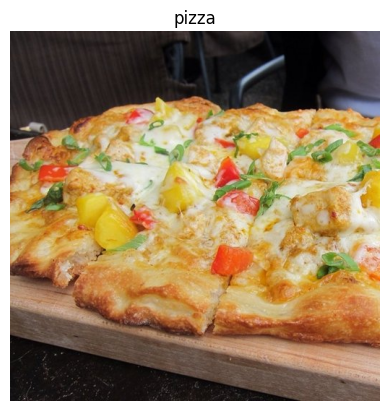

In [17]:
# View a random image from the training dataset
img = view_random_image(target_dir='pizza_steak/train/',
                        target_class='pizza')

In [18]:
224,224,3

(224, 224, 3)

In [19]:
# The images we've imported and plotted are actually giant arrays/tensors of different pixel values
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
tf.constant(img)

Num GPUs Available: 1


2026-04-17 10:47:45.290797: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-17 10:47:45.290991: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-17 10:47:45.291015: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-17 10:47:45.291802: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-17 10:47:45.292270: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[ 39,  35,  34],
        [ 40,  36,  35],
        [ 39,  35,  34],
        ...,
        [ 95,  94, 112],
        [ 94,  93, 111],
        [ 93,  92, 110]],

       [[ 38,  34,  33],
        [ 39,  35,  34],
        [ 39,  35,  34],
        ...,
        [ 96,  95, 113],
        [ 95,  94, 112],
        [ 94,  93, 111]],

       [[ 37,  33,  32],
        [ 38,  34,  33],
        [ 38,  34,  33],
        ...,
        [ 97,  96, 114],
        [ 96,  95, 113],
        [ 96,  95, 113]],

       ...,

       [[ 19,  17,  20],
        [ 19,  17,  20],
        [ 19,  17,  20],
        ...,
        [107,  83,  71],
        [107,  83,  71],
        [108,  84,  72]],

       [[ 20,  18,  21],
        [ 20,  18,  21],
        [ 19,  17,  20],
        ...,
        [105,  81,  69],
        [106,  82,  70],
        [107,  83,  71]],

       [[ 22,  20,  23],
        [ 23,  21,  24],
        [ 22,  20,  23],
        ...,
        [104,  80,  6

In [20]:
# View the image shape
img.shape # returns width, height, colour channels

(512, 512, 3)

In [21]:
# Get all the pixel values between 0 & 1 (scale/normalize the data, as neural networks love values between 0 & 1)
img/255

array([[[0.15294118, 0.1372549 , 0.13333333],
        [0.15686275, 0.14117647, 0.1372549 ],
        [0.15294118, 0.1372549 , 0.13333333],
        ...,
        [0.37254902, 0.36862745, 0.43921569],
        [0.36862745, 0.36470588, 0.43529412],
        [0.36470588, 0.36078431, 0.43137255]],

       [[0.14901961, 0.13333333, 0.12941176],
        [0.15294118, 0.1372549 , 0.13333333],
        [0.15294118, 0.1372549 , 0.13333333],
        ...,
        [0.37647059, 0.37254902, 0.44313725],
        [0.37254902, 0.36862745, 0.43921569],
        [0.36862745, 0.36470588, 0.43529412]],

       [[0.14509804, 0.12941176, 0.1254902 ],
        [0.14901961, 0.13333333, 0.12941176],
        [0.14901961, 0.13333333, 0.12941176],
        ...,
        [0.38039216, 0.37647059, 0.44705882],
        [0.37647059, 0.37254902, 0.44313725],
        [0.37647059, 0.37254902, 0.44313725]],

       ...,

       [[0.0745098 , 0.06666667, 0.07843137],
        [0.0745098 , 0.06666667, 0.07843137],
        [0.0745098 , 0

### An end-to-end example
Let's build a convolutional neural network to find patterns in our images, more specifically we a need way to:

- Load our images
- Preprocess our images
- Build a CNN to find patterns in our images
- Compile our CNN
- Fit the CNN to our training data

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the seed
tf.random.set_seed(42)

# Preprocess data (get all of the pixel values between 0 & 1 ,also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup paths to our data directories
train_dir = 'pizza_steak/train'
test_dir = 'pizza_steak/test'

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory = train_dir,
                                               batch_size = 32,
                                               target_size =(224,224),
                                               class_mode = 'binary',
                                               seed = 42)
valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size = 32,
                                               target_size=(224,224),
                                               class_mode = 'binary',
                                               seed = 42)

# Build a CNN model (same as the Tiny VGG on the CNN explainer website)
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=3,
                           activation='relu',
                           input_shape = (224,224,3)),
    tf.keras.layers.Conv2D(10,3,activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2,
                              padding = 'valid'),
    tf.keras.layers.Conv2D(10,3,activation='relu'),
    tf.keras.layers.Conv2D(10,3,activation='relu'),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

# Compile our CNN
model_1.compile(loss='binary_crossentropy',
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

# Fit the  Model
history_1 = model_1.fit(train_data,
                        epochs = 5,
                        steps_per_epoch = len(train_data),
                        validation_data = valid_data,
                        validation_steps = len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/Users/fahimp/Desktop/Python_Frameworks/Deeplearning-with_tensorflow/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


2026-04-17 10:47:46.259017: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.6953 - loss: 0.5573 - val_accuracy: 0.8080 - val_loss: 0.3864
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.8147 - loss: 0.4202 - val_accuracy: 0.8580 - val_loss: 0.3326
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.8233 - loss: 0.3950 - val_accuracy: 0.8720 - val_loss: 0.3250
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.8480 - loss: 0.3523 - val_accuracy: 0.8760 - val_loss: 0.3015
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.8680 - loss: 0.3285 - val_accuracy: 0.8820 - val_loss: 0.3193


In [23]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

In [24]:
train_data

In [25]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape = (224,224,3)),
    tf.keras.layers.Dense(4,activation='relu'),
    tf.keras.layers.Dense(4,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model_2.compile(loss = 'binary_crossentropy',
                optimizer = tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch = len(train_data),
                        validation_data=valid_data,
                        validation_steps = len(valid_data))

Epoch 1/5


/Users/fahimp/Desktop/Python_Frameworks/Deeplearning-with_tensorflow/tf-env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.4940 - loss: 977.2105 - val_accuracy: 0.5000 - val_loss: 1837.4139
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5000 - loss: 2367.7971 - val_accuracy: 0.5000 - val_loss: 2790.3357
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5000 - loss: 2638.2708 - val_accuracy: 0.5000 - val_loss: 2241.4287
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4960 - loss: 1097.1206 - val_accuracy: 0.5000 - val_loss: 238.5900
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5133 - loss: 55.0450 - val_accuracy: 0.5720 - val_loss: 3.8652


In [26]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │       602,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,806,425 (6.89 MB)

 Trainable params: 602,141 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,204,284 (4.59 MB)

In [28]:
tf.random.set_seed(42)

model_3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape = (224,224,3)),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid'),
])
model_3.compile(loss = 'binary_crossentropy',
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ['accuracy'])
history_3=model_3.fit(train_data,
                      epochs= 5,
                      steps_per_epoch = len(train_data),
                      validation_data = valid_data,
                      validation_steps = len(valid_data))

/Users/fahimp/Desktop/Python_Frameworks/Deeplearning-with_tensorflow/tf-env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.6653 - loss: 12.6931 - val_accuracy: 0.7240 - val_loss: 8.1623
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7053 - loss: 7.3829 - val_accuracy: 0.7660 - val_loss: 3.7961
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7247 - loss: 4.5117 - val_accuracy: 0.7900 - val_loss: 2.8892
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7100 - loss: 3.7414 - val_accuracy: 0.7520 - val_loss: 2.7370
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7280 - loss: 2.5981 - val_accuracy: 0.7180 - val_loss: 1.9632


In [29]:
model_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │    15,052,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,219,605 (172.50 MB)

 Trainable params: 15,073,201 (57.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,146,404 (115.00 MB)

In [30]:
15000000/31000

483.8709677419355

## Binary Classification: Let's break it down
1. Become one with the data (visualize, visualize, visualize)
2. Preprocess the data (prepared it for our model, the main step here was scaling/normalizing & turning our data into batches)
3. Create a model (start with a baseline)
4. Fit the model
5. Evaluate the model
6. Adjust different parameters and improve the model (try to beat our baseline)
7. Repeat until satisfied (experiment, experiment, experiment)

### 1. Become one with the data

['2395127.jpg']
Image shape : (384, 512, 3)
['1678284.jpg']
Image shape : (512, 384, 3)


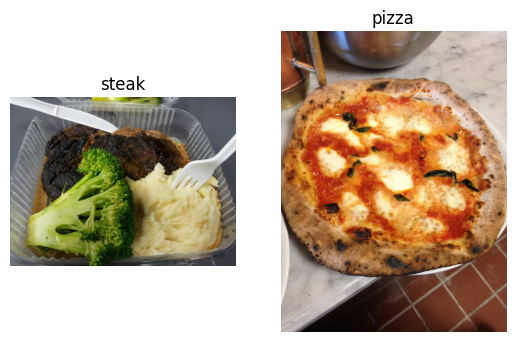

In [31]:
# Visualize data
plt.figure()
plt.subplot(1, 2, 1)
steak_img = view_random_image("pizza_steak/train/", "steak")
plt.subplot(1, 2, 2)
pizza_img = view_random_image("pizza_steak/train/", "pizza")

### 2. Preprocess the data (prepare it for a model)

In [32]:
# Define directory dataset paths
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

In [ ]:
# Create train and test data generators and rescale the data
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1/255)
test_datagen = ImageDataGenerator(rescale=1/255)

In [36]:
# Load in our image data from directories and turn them into batches
train_data = train_datagen.flow_from_directory(directory=train_dir, # Target directoy of images
                                               target_size=(224, 224), # Target size of images (height, width)
                                               class_mode="binary", # type of data you're working with
                                               batch_size=32) # size of minibatches to load data into

test_data = test_datagen.flow_from_directory(directory=test_dir,
                                             target_size = (224,224),
                                             class_mode = 'binary',
                                             batch_size = 32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [41]:
# Get a sample of a train data batch
images, labels = next(train_data)# get the "next" batch of images/labels in train_data
len(images), len(labels)

(32, 32)

In [42]:
# How many batches are there?
len(train_data)

47

In [43]:
1500/32

46.875

In [ ]:
# Get the first two images
images[:2], images[0].shape

(array([[[[0.56078434, 0.63529414, 0.79215693],
          [0.5647059 , 0.6392157 , 0.7960785 ],
          [0.5647059 , 0.6392157 , 0.80392164],
          ...,
          [0.07843138, 0.08235294, 0.05882353],
          [0.08235294, 0.08235294, 0.07450981],
          [0.09803922, 0.09803922, 0.09803922]],
 
         [[0.5647059 , 0.6392157 , 0.7960785 ],
          [0.5568628 , 0.6313726 , 0.7960785 ],
          [0.5568628 , 0.6313726 , 0.7960785 ],
          ...,
          [0.09803922, 0.10196079, 0.07058824],
          [0.0627451 , 0.06666667, 0.04705883],
          [0.04313726, 0.04313726, 0.03529412]],
 
         [[0.5686275 , 0.6431373 , 0.8078432 ],
          [0.5647059 , 0.6392157 , 0.80392164],
          [0.5647059 , 0.6392157 , 0.8078432 ],
          ...,
          [0.07450981, 0.07843138, 0.04705883],
          [0.15686275, 0.16078432, 0.13725491],
          [0.21568629, 0.21960786, 0.20000002]],
 
         ...,
 
         [[0.3921569 , 0.34901962, 0.22352943],
          [0.39607

In [45]:
images[7]

array([[[0.2784314 , 0.21960786, 0.20784315],
        [0.3254902 , 0.2627451 , 0.2627451 ],
        [0.36078432, 0.29803923, 0.29803923],
        ...,
        [0.3137255 , 0.3529412 , 0.32156864],
        [0.11764707, 0.19607845, 0.15294118],
        [0.11764707, 0.21176472, 0.15686275]],

       [[0.30588236, 0.24705884, 0.23529413],
        [0.3372549 , 0.27450982, 0.27450982],
        [0.36862746, 0.30588236, 0.30980393],
        ...,
        [0.24705884, 0.28627452, 0.25490198],
        [0.34117648, 0.40784317, 0.36862746],
        [0.21568629, 0.3019608 , 0.25490198]],

       [[0.3019608 , 0.24705884, 0.23529413],
        [0.32941177, 0.27450982, 0.27058825],
        [0.3529412 , 0.29803923, 0.29803923],
        ...,
        [0.18431373, 0.21176472, 0.18431373],
        [0.14509805, 0.19607845, 0.16078432],
        [0.30980393, 0.38823533, 0.34509805]],

       ...,

       [[0.32941177, 0.26666668, 0.16862746],
        [0.34117648, 0.27058825, 0.1764706 ],
        [0.3372549 , 0

In [46]:
labels

array([0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1.],
      dtype=float32)

### 3. Create a CNN model (start with a baseline)

In [47]:
# Make the creating of our model a little easier
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPool2D,Activation
from tensorflow.keras import Sequential

In [48]:
# Create the model (this will be our baseline, a layer convolutional neural network)
model_4 = Sequential([
  Conv2D(filters=10, # filter is the number of sliding windows going across an input (higher = more complex model)
         kernel_size=(3, 3), # the size of the sliding window going across an input
         strides=(1, 1), # the size of the step the sliding window takes across an input 
         padding="valid", # if "same", output shape is same as input shape, if "valid", output shape gets compressed
         activation="relu",
         input_shape=(224, 224, 3)), # input layer (specify input shape)
  Conv2D(10, 3, activation="relu"),
  Conv2D(10, 3, activation="relu"),
  Flatten(),
  Dense(1, activation="sigmoid") # output layer (working with binary classification so only 1 output neuron)                 
])

/Users/fahimp/Desktop/Python_Frameworks/Deeplearning-with_tensorflow/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
model_4.compile(loss='binary_crossentropy',
                optimizer = Adam(),
                metrics = ['accuracy'])

In [50]:
model_4.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 218, 218, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 475240)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │       475,241 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,341 (1.82 MB)

 Trainable params: 477,341 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Fit the model

In [51]:
len(train_data)

47

In [52]:
len(test_data)

16

In [ ]:
history_4 = model_4.fit(train_data, # this is a combination of labels and sample data
                        epochs = 5,
                        steps_per_epoch = len(train_data), #batch
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.7073 - loss: 0.8489 - val_accuracy: 0.8160 - val_loss: 0.4328
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.8407 - loss: 0.3901 - val_accuracy: 0.8340 - val_loss: 0.4132
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9240 - loss: 0.2275 - val_accuracy: 0.8320 - val_loss: 0.3898
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9707 - loss: 0.1090 - val_accuracy: 0.7980 - val_loss: 0.5068
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9967 - loss: 0.0286 - val_accuracy: 0.7660 - val_loss: 0.6229


In [54]:
model_4.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 218, 218, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 475240)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │       475,241 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,432,025 (5.46 MB)

 Trainable params: 477,341 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 954,684 (3.64 MB)

### 5. Evaluating our model

In [58]:
import pandas as pd

pd.DataFrame(history_4.history)

,accuracy,loss,val_accuracy,val_loss
0,0.707333,0.848871,0.816,0.432798
1,0.840667,0.390127,0.834,0.413158
2,0.924000,0.227466,0.832,0.389786
3,0.970667,0.109007,0.798,0.506802
4,0.996667,0.028626,0.766,0.622877


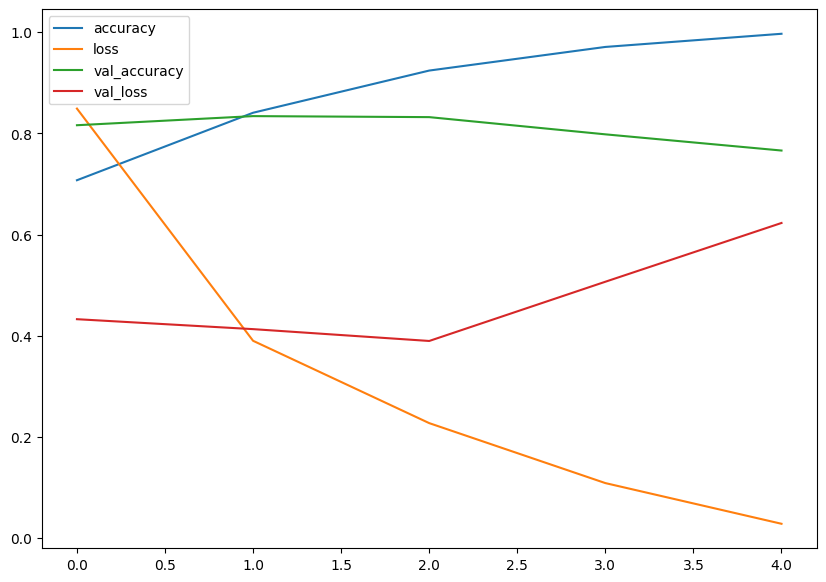

In [59]:
pd.DataFrame(history_4.history).plot(figsize=(10,7));

In [60]:
# Plot the validation and training curves separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """
  loss = history.history["loss"]
  val_loss = history.history["val_loss"]

  accuracy = history.history["accuracy"]
  val_accuracy = history.history["val_accuracy"]

  epochs = range(len(history.history["loss"])) # how many epochs did we run for?

  # Plot loss
  plt.plot(epochs, loss, label="training_loss")
  plt.plot(epochs, val_loss, label="val_loss")
  plt.title("loss")
  plt.xlabel("epochs")
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label="training_accuracy")
  plt.plot(epochs, val_accuracy, label="val_accuracy")
  plt.title("accuracy")
  plt.xlabel("epochs")
  plt.legend();

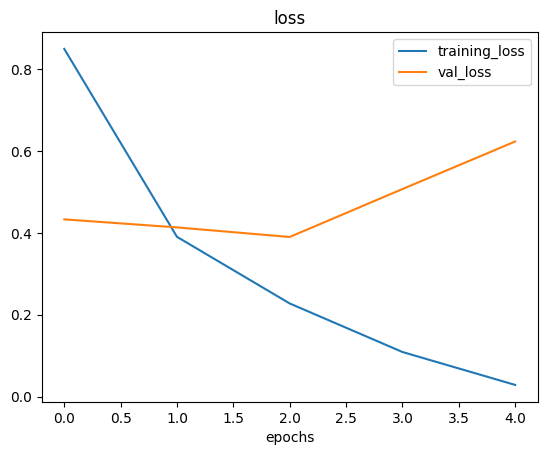

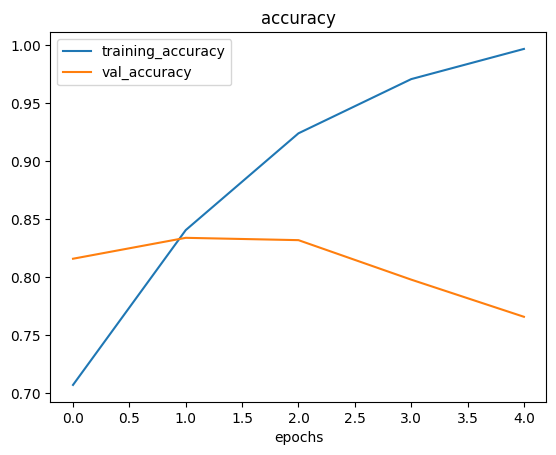

In [61]:
# Check out the loss and accuracy of model_4
plot_loss_curves(history_4)

`🔑 Note: Ideally the two loss curves (training and validation) will be very similar to each other (training loss and validation loss decreasing at similar rates), when there are large differences your model may be overfitting`

### 6. Adjust the model parameters

> Fitting a machine learning model comes in 3 steps:

- Create a baseline
- Beat the baseline by overfitting a larger model
- Reduce overfitting
> Ways to induce overfitting:

- Increase the number of conv layers
- Increase the number of conv filters
- Add another dense layer to the output of our flattened layer
> Reduce overfitting:

- Add data augmentation
- Add regularization layers (such as MaxPool2D)
- Add more data...

> `🔑 Note: Reducing overfitting is also known as regularization.`